# theta_interpretation: scalar 1D Gaussian MGD experiment

Goal: fit MGD/SDE maximum-entropy potentials directly on **scalar** 1D
Gaussian data, `x1 ~ N(0, data_sigma^2)`, and look at what the fitted
`theta_t` does under:

1. A **correctly-specified** potential set, `terms=['x2']` — the sufficient
   statistic of a Gaussian.
2. A **misspecified** potential set, `terms=['x2', 'x4']` — adding a term
   the true distribution doesn't need, to see whether the fit correctly
   drives `theta_x4` toward 0 while leaving `theta_x2` essentially unchanged.

**Data layout note:** this is genuinely scalar data, shape `(n1, 1)` — NOT
`(n1, 1, 1)`. `codes/sde_routines.py`'s `SDE` class dispatches on
`len(x_1.shape)`: `2 -> (B, C)` scalar (no wavelet machinery), `3 -> (B, C, T)`
1D field (wavelet scattering over the last axis). A single real number per
sample has no signal-length axis to convolve over, so this experiment uses
the scalar branch and `get_scalar_potentials()` (pointwise `Monomial`
potentials) from `codes/potentials_builder.py`, not the wavelet-scattering
`get_1d_potentials()` the other `run_SDE.py` entry points (jets/turbulence/
gaussian_experiment) use — those work in a genuinely higher-dimensional
`(n_samples, 1, M)` signal space, e.g. `M=128`, which is what "the usual
`(128, 1, 1000)`-shaped data" actually means: `128` samples of a
1000-dimensional field, not a 128-dimensional space sampled 1000 times.

This notebook imports and reuses the functions defined in `run_SDE.py`
(this folder) rather than redefining them, so the notebook and the CLI
script can never drift apart on the run/save/naming logic.


In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

root = Path.cwd()
if not (root / 'run_SDE.py').exists():
    root = root / 'theta_interpretation'  # allow running the notebook from the repo root
sys.path.insert(0, str(root))
sys.path.insert(0, str(root.parent / 'codes'))

from run_SDE import (
    make_args,
    run_and_diagnose,
    get_scalar_potentials,
    plot_theta_reg_overlay,
    device,
)
from utils_entropy import entropy_bound, log_Z_bound  # codes/utils_entropy.py, on sys.path via codes/

print('device:', device)


device: cuda


## Expected `theta_x2` 

`codes/sde_routines.py` fits a maximum-entropy density of the form
`p(x) ∝ exp( sum_i theta_i * phi_i(x) )`. This sign/scale convention is
taken from the legacy `notebooks/mgd_sampling/mgd_scalar_example.ipynb`,
which printed a `Target theta` matching it for a quartic target — it has
**not** been independently re-derived against the current `SDE`/
`forward_regularised` implementation, so treat it as a hypothesis to check
against the actual runs below, not a verified fact.

For `phi(x) = x^2` and target `N(0, sigma_data^2)`:

```
p(x) ∝ exp(-x^2 / (2 sigma_data^2))   =>   theta_x2 = -1 / (2 sigma_data^2)
```

For the misspecified set `phi = (x^2, x^4)`, since the true density needs
no quartic term, the expectation is `theta_x2` essentially unchanged and
`theta_x4 -> 0`.


In [2]:
# make_args()/run_and_diagnose() are imported from run_SDE.py above --
# defined there (not here) so this notebook and the CLI script share the
# exact same run/save/naming logic.

# ── Notebook-local parameter overrides ──────────────────────────────────────
# make_args(terms, **overrides) fills in everything you don't pass from its
# own defaults dict in run_SDE.py, which mirror parse_args()'s CLI defaults.
# `run_and_diagnose(make_args(['x2'], outdir=str(root)))` below only overrides
# `terms`/`outdir`, so every other value (n1, nt, sigma, ...) was silently
# falling back to those defaults -- editing run_SDE.py's argparse defaults is
# NOT the way to change what a notebook run uses. Edit PARAM_OVERRIDES here
# instead, then re-run this cell and the Run 1 / Run 2 cells below.
#
# Different values here produce a different config name (build_config_name()
# hashes n1/data_sigma/sigma/nt/lam/seed/terms), so past runs are never
# silently reused across different parameters -- only FORCE_RERUN controls
# whether an exact repeat of the same parameters re-fits from scratch instead
# of loading the cached result.
N1 = 50002
DATA_SIGMA = 1.0
NT = 1000
SIGMA = 1.0                # SDE diffusion coefficient (distinct from DATA_SIGMA)
SCHEDULE_EXPONENT = 2
INTERPOLANT = 'Cos'
REGULARIZATION = 1e-3
LAM = 5e-7
N_SUBSAMPLE = 1
BATCH_SIZE = None
N_BINS = 30
MOMENT_THRESHOLD = 1e-8
SEED = 0
FORCE_RERUN = False          # True: ignore any cached result and refit
NO_SAVE_AUX_MOMENTS = False

PARAM_OVERRIDES = dict(
    n1=N1, data_sigma=DATA_SIGMA, nt=NT, sigma=SIGMA,
    schedule_exponent=SCHEDULE_EXPONENT, interpolant=INTERPOLANT,
    regularization=REGULARIZATION, lam=LAM, n_subsample=N_SUBSAMPLE,
    batch_size=BATCH_SIZE, n_bins=N_BINS, moment_threshold=MOMENT_THRESHOLD,
    seed=SEED, force_rerun=FORCE_RERUN, no_save_aux_moments=NO_SAVE_AUX_MOMENTS,
)

## Run 1: correctly-specified potential, `terms=['x2']`


In [3]:
run_correct = run_and_diagnose(make_args(['x2'], outdir=str(root), **PARAM_OVERRIDES))

2026-09-04 11:04:39  INFO      Config: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_seed_0_terms8e683187
2026-09-04 11:04:39  INFO      Experiment folder: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/experiments/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_terms8e683187/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_seed_0_terms8e683187
2026-09-04 11:04:39  INFO      Arguments: {'timestamp': None, 'n1': 50002, 'data_sigma': 1.0, 'terms': ['x2'], 'nt': 1000, 'sigma': 1.0, 'schedule_exponent': 2, 'interpolant': 'Cos', 'regularization': 0.001, 'lam': 5e-07, 'n_subsample': 1, 'batch_size': None, 'n_bins': 30, 'moment_threshold': 1e-08, 'outdir': '/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation', 'label': None, 'force_rerun': False, 'no_save_aux_moments': False, 'seed': 0}
2026-09-04 11:04:39  INFO      Running experiment: thetainterp_sigmadata1.0_sigm

1000it [00:02, 412.14it/s]


Loop finished
After loop: CPU=1.01 GB | GPU alloc=0.04 GB | GPU reserved=0.04 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.01 GB | GPU alloc=0.04 GB | GPU reserved=0.04 GB
Dropped close-in-time nodes: 3
Last times: [0.99993598 0.999951   0.999964   0.99997503 0.999991  ]
Last dt: [1.50203705e-05 1.29938126e-05 1.10268593e-05 1.59740448e-05]
Calling torch.linalg.solve
Before solve: CPU=1.04 GB | GPU alloc=0.05 GB | GPU reserved=0.06 GB
Solve finished
After solve: CPU=1.12 GB | GPU alloc=0.05 GB | GPU reserved=0.06 GB
After _solve_regularised: CPU=1.12 GB | GPU alloc=0.04 GB | GPU reserved=0.06 GB
Stacking outputs
Everything stacked: CPU=1.12 GB | GPU alloc=0.04 GB | GPU reserved=0.06 GB
Returning
2026-09-04 11:04:42  INFO      SDE integration finished in 3.0 s
2026-09-04 11:04:43  INFO      Final theta (order matches ['x2']): [-2.0819990634918213]
2026-09-04 11:04:43  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(sum

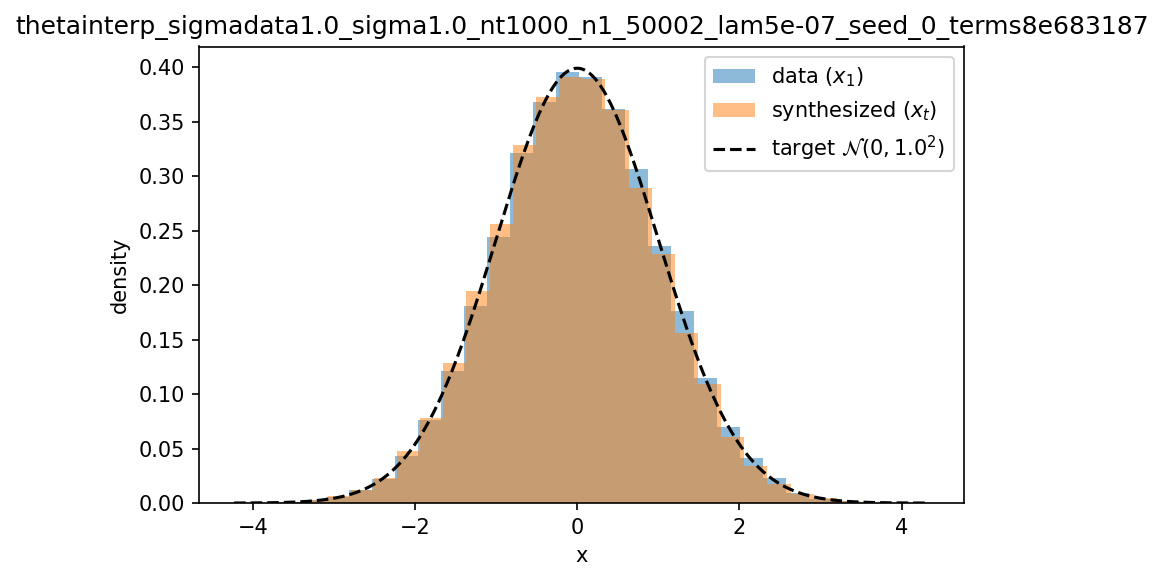

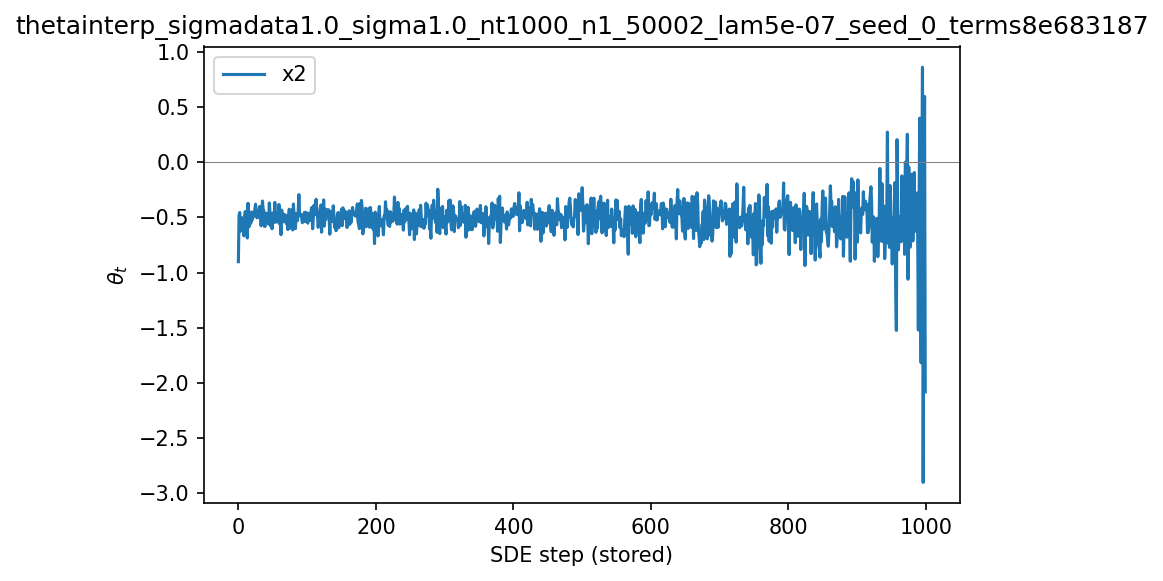

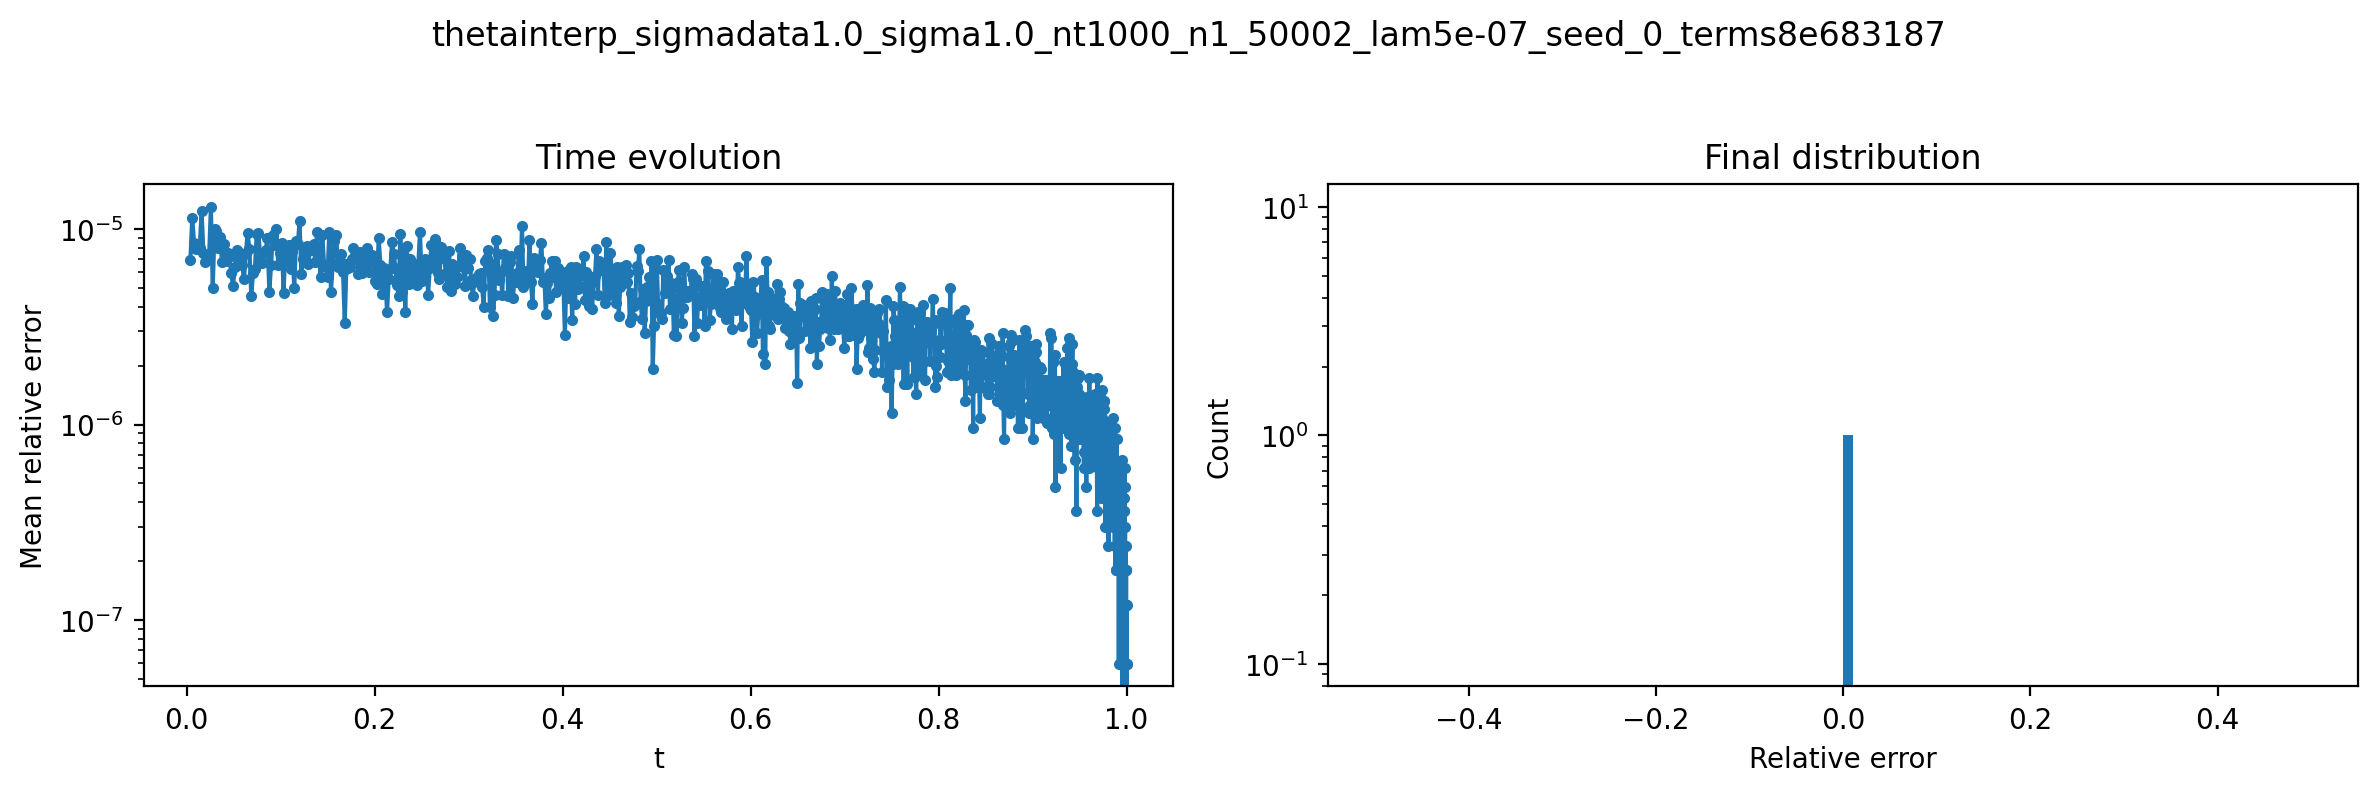

In [4]:
display(Image(filename=str(run_correct['fig_dir'] / 'marginal_histogram.png')))
display(Image(filename=str(run_correct['fig_dir'] / 'theta_trajectory.png')))
display(Image(filename=str(run_correct['fig_dir'] / 'moment_matching.png')))


### Diagnostics: moment matching, entropy bound, regularised vs. raw theta

- **Moment matching** (`moment_matching.png`, already produced by
  `save_diagnostics` in `run_SDE.py`): relative error between the
  interpolant's target moments and the walkers' empirical moments over
  time. If this blows up or never drops below `moment_threshold`, the run
  didn't converge -- don't trust anything else below.
- **Entropy bound check**: `codes/utils_entropy.py`'s `log_Z_bound` (MGD
  Eq. 8) against the *exact* analytic Gaussian `log Z`, which we know here
  because the data-generating process really is `N(0, data_sigma^2)`.
  Also surfaces `entropy_bound`'s own quadrature diagnostics
  (`quadrature_gap`, `refinement`) and `log_Z_bound`'s `m1_discrepancy` --
  use these to judge whether `nt` / `n_subsample` / `lam` are well-tuned
  *before* spending compute on a multi-seed sweep.
- **`theta_t` vs `Theta_reg` overlay**: the raw per-step MGD fit against
  the time-regularised solve, to see what the regularisation is actually
  doing to the trajectory.


In [5]:
potentials_correct = get_scalar_potentials(run_correct['args'].terms)
term_names_correct = list(potentials_correct.keys())
results_correct = {'run_correct': run_correct['result']}

eb_reg = log_Z_bound(results_correct, 'run_correct', 'Theta_reg', potentials_correct, device=device)
eb_raw = log_Z_bound(results_correct, 'run_correct', 'theta_t', potentials_correct, device=device)

log_Z_analytic = 0.5 * np.log(2 * np.pi * run_correct['args'].data_sigma**2)

print('log_Z_bound (Theta_reg) :', eb_reg['log_Z_bound'])
print('log_Z_bound (theta_t)   :', eb_raw['log_Z_bound'])
print('log_Z_analytic          :', log_Z_analytic)
print()
print('H_bound          :', eb_reg['entropy_bound']['H_bound'])
print('quadrature_gap   :', eb_reg['entropy_bound']['quadrature_gap'],
      '  (trapezoid - left_riemann; large relative to H_bound => nt may be too coarse)')
print('refinement drift :', eb_reg['entropy_bound']['refinement'])
print()
print('m1_discrepancy (Theta_reg)      :', eb_reg['m1_discrepancy'],
      '  (||target - particle moments|| / ||target||; large => corrector/n_subsample/lam not converged)')
print('theta1.m1 bootstrap std (Theta_reg):', eb_reg['theta1_dot_m1_bootstrap_std'])


log_Z_bound (Theta_reg) : 1.1727305066069307
log_Z_bound (theta_t)   : -0.6517062324801741
log_Z_analytic          : 0.9189385332046727

H_bound          : 1.4197342258175554
quadrature_gap   : -1.2794043868780136e-06   (trapezoid - left_riemann; large relative to H_bound => nt may be too coarse)
refinement drift : {'every_2nd': {'trapezoid': 0.0007884928490966558, 'drift_from_full': -7.199763786047697e-06}, 'every_4th': {'trapezoid': 0.0007635570364072919, 'drift_from_full': -3.2135576475411654e-05}}

m1_discrepancy (Theta_reg)      : 0.0   (||target - particle moments|| / ||target||; large => corrector/n_subsample/lam not converged)
theta1.m1 bootstrap std (Theta_reg): 0.001424396707737348


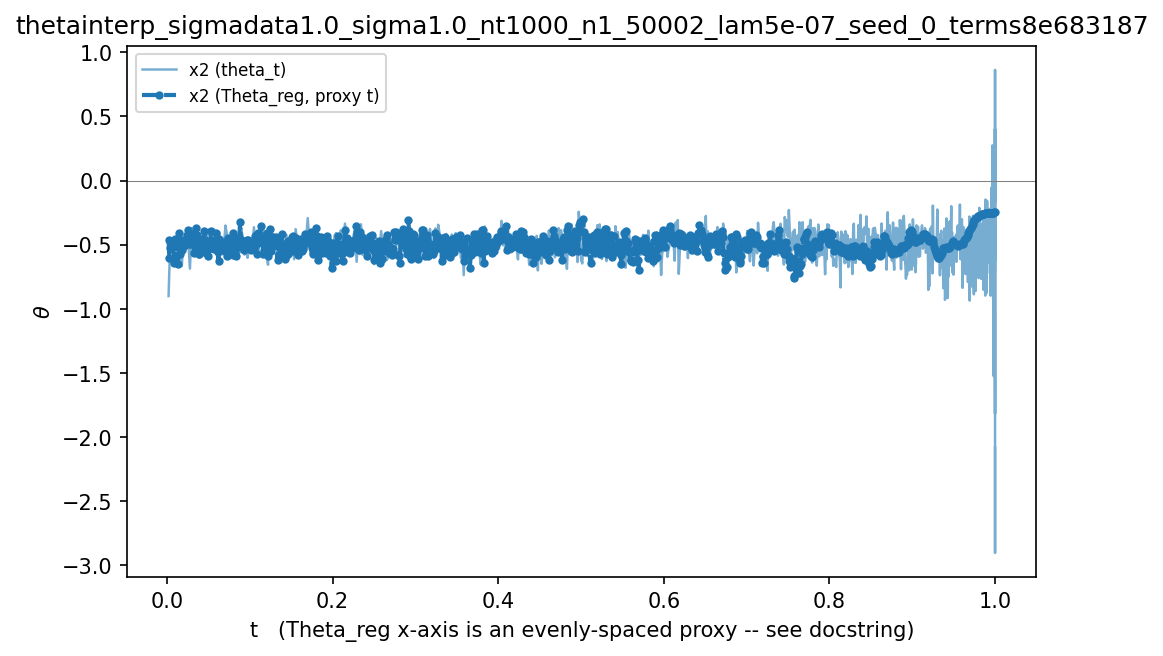

In [6]:
plot_theta_reg_overlay(
    run_correct['result']['theta_t'], run_correct['result']['Theta_reg'],
    run_correct['result']['t'], term_names_correct,
    run_correct['fig_dir'], run_correct['config'],
)
display(Image(filename=str(run_correct['fig_dir'] / 'theta_reg_overlay.png')))


In [7]:
term_names_correct = list(get_scalar_potentials(run_correct['args'].terms).keys())
theta_final_correct = run_correct['result']['theta_t'][-1].detach().cpu()
target_theta_x2 = -1.0 / (2 * run_correct['args'].data_sigma**2)

print('terms:', term_names_correct)
print('fitted theta[-1]:', theta_final_correct.tolist())
print('reference target theta_x2 (see derivation above, unverified):', target_theta_x2)


terms: ['x2']
fitted theta[-1]: [-2.0819990634918213]
reference target theta_x2 (see derivation above, unverified): -0.5


## Run 2: misspecified potential, `terms=['x2', 'x4']`


In [8]:
run_wrong = run_and_diagnose(make_args(['x2', 'x4'], outdir=str(root), **PARAM_OVERRIDES))

2026-09-04 11:05:00  INFO      Config: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_seed_0_termsaddb4eb1
2026-09-04 11:05:00  INFO      Experiment folder: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/experiments/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_termsaddb4eb1/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50002_lam5e-07_seed_0_termsaddb4eb1
2026-09-04 11:05:00  INFO      Arguments: {'timestamp': None, 'n1': 50002, 'data_sigma': 1.0, 'terms': ['x2', 'x4'], 'nt': 1000, 'sigma': 1.0, 'schedule_exponent': 2, 'interpolant': 'Cos', 'regularization': 0.001, 'lam': 5e-07, 'n_subsample': 1, 'batch_size': None, 'n_bins': 30, 'moment_threshold': 1e-08, 'outdir': '/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation', 'label': None, 'force_rerun': False, 'no_save_aux_moments': False, 'seed': 0}
2026-09-04 11:05:00  INFO      Running experiment: thetainterp_sigmadata1.

1000it [00:02, 439.81it/s]


Loop finished
After loop: CPU=1.16 GB | GPU alloc=0.04 GB | GPU reserved=0.06 GB
Preparing regularised solve
Before _solve_regularised: CPU=1.15 GB | GPU alloc=0.04 GB | GPU reserved=0.06 GB
Dropped close-in-time nodes: 3
Last times: [0.99993598 0.999951   0.999964   0.99997503 0.999991  ]
Last dt: [1.50203705e-05 1.29938126e-05 1.10268593e-05 1.59740448e-05]
Calling torch.linalg.solve
Before solve: CPU=1.15 GB | GPU alloc=0.07 GB | GPU reserved=0.11 GB
Solve finished
After solve: CPU=1.15 GB | GPU alloc=0.07 GB | GPU reserved=0.11 GB
After _solve_regularised: CPU=1.15 GB | GPU alloc=0.04 GB | GPU reserved=0.11 GB
Stacking outputs
Everything stacked: CPU=1.15 GB | GPU alloc=0.04 GB | GPU reserved=0.11 GB
Returning
2026-09-04 11:05:03  INFO      SDE integration finished in 2.8 s
2026-09-04 11:05:04  INFO      Final theta (order matches ['x2', 'x4']): [-2.8022193908691406, 0.11775221675634384]
2026-09-04 11:05:04  INFO      Reference (unverified against this run): for target N(0, data_si

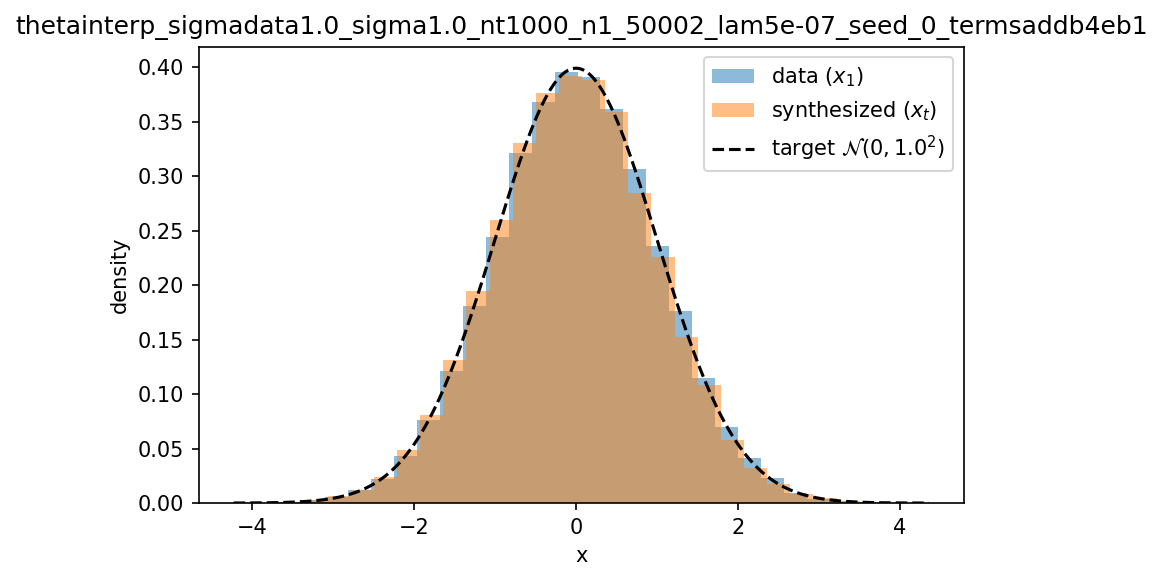

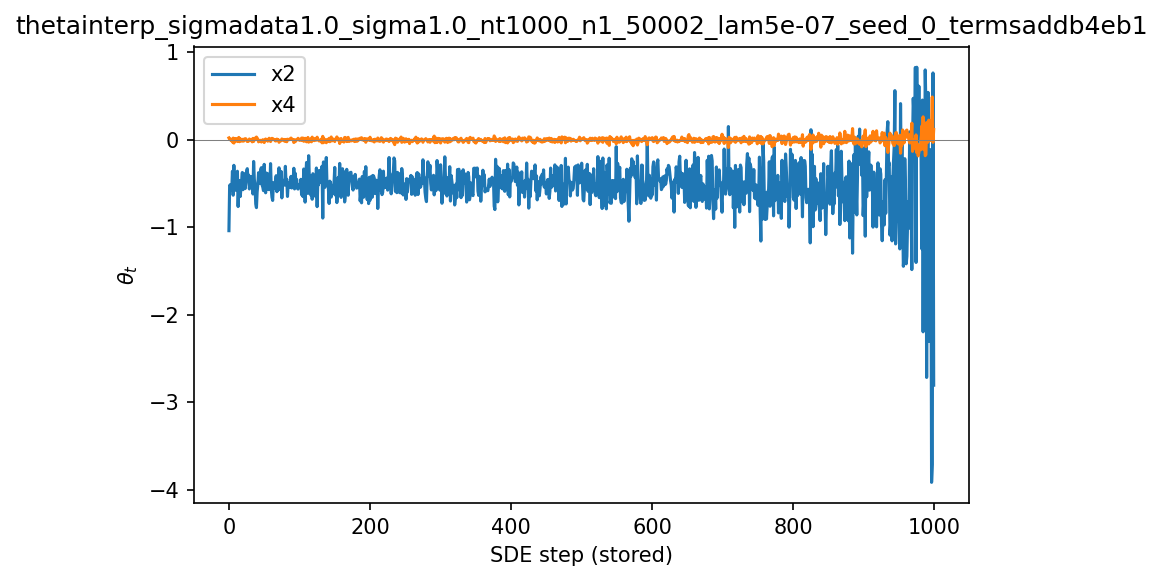

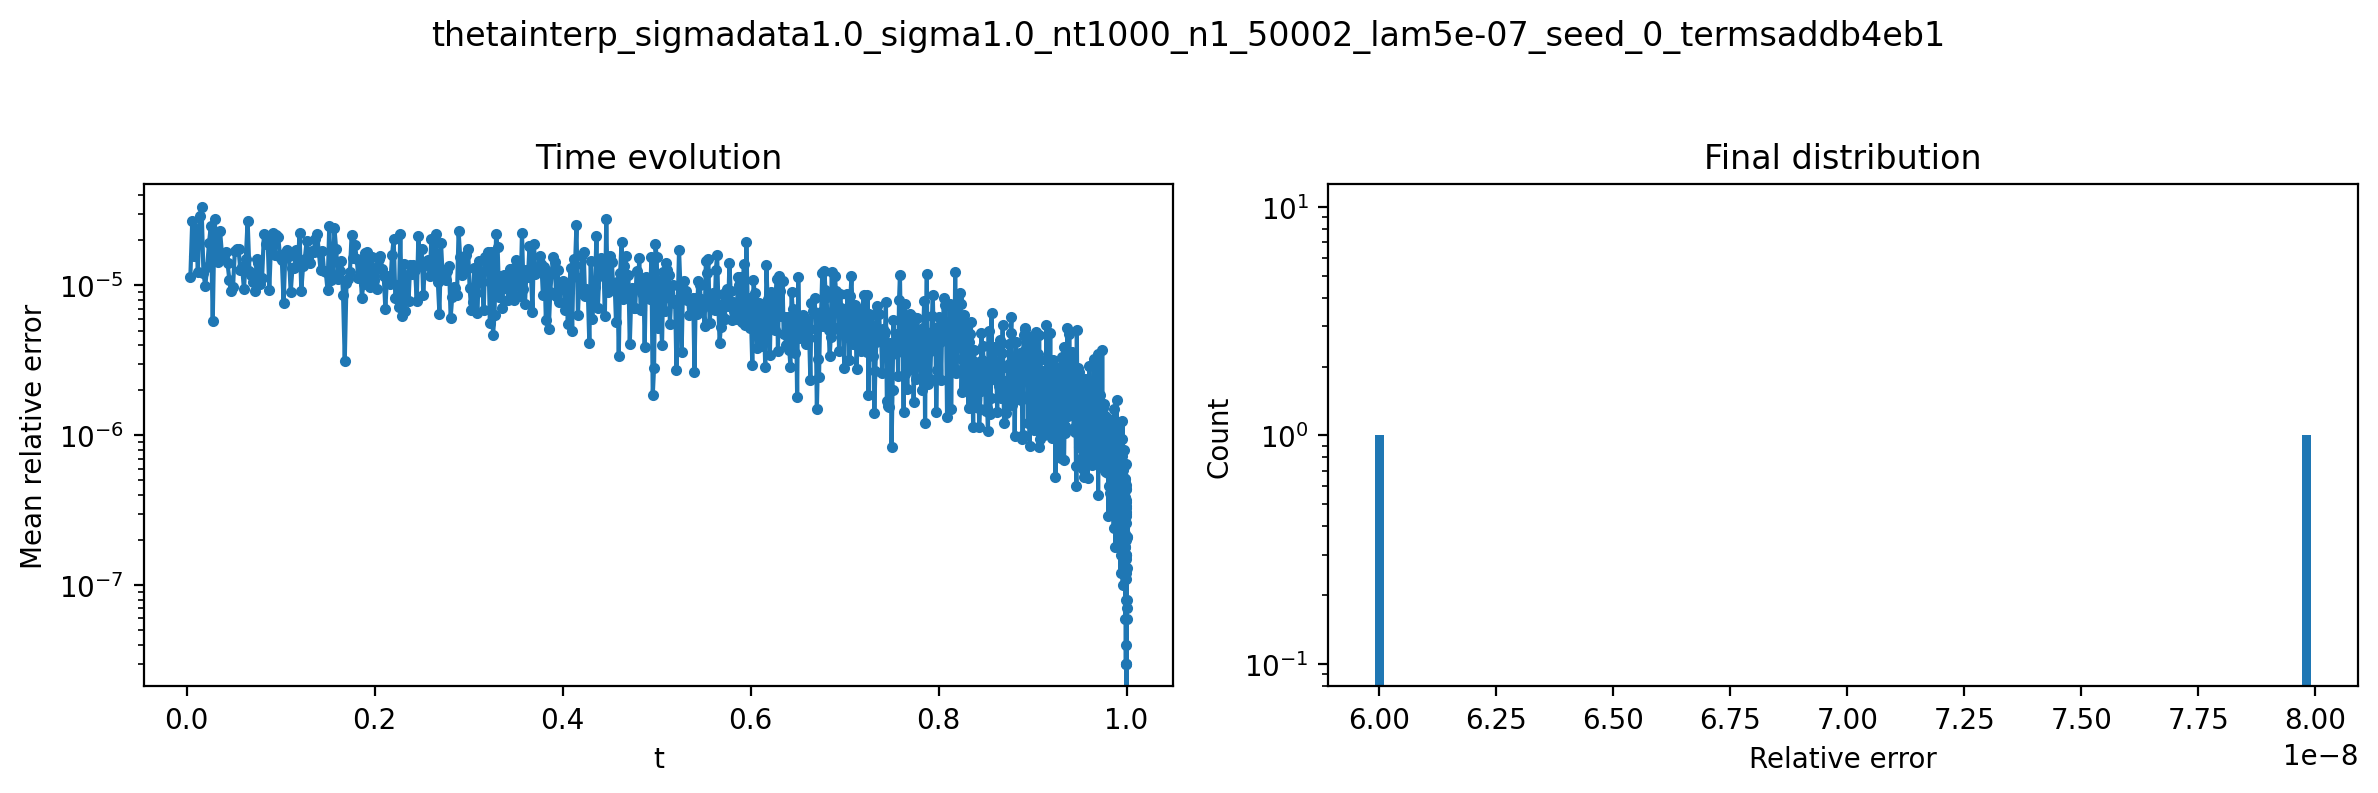

In [9]:
display(Image(filename=str(run_wrong['fig_dir'] / 'marginal_histogram.png')))
display(Image(filename=str(run_wrong['fig_dir'] / 'theta_trajectory.png')))
display(Image(filename=str(run_wrong['fig_dir'] / 'moment_matching.png')))


### Diagnostics: moment matching, entropy bound, regularised vs. raw theta

- **Moment matching** (`moment_matching.png`, already produced by
  `save_diagnostics` in `run_SDE.py`): relative error between the
  interpolant's target moments and the walkers' empirical moments over
  time. If this blows up or never drops below `moment_threshold`, the run
  didn't converge -- don't trust anything else below.
- **Entropy bound check**: `codes/utils_entropy.py`'s `log_Z_bound` (MGD
  Eq. 8) against the *exact* analytic Gaussian `log Z`, which we know here
  because the data-generating process really is `N(0, data_sigma^2)`.
  Also surfaces `entropy_bound`'s own quadrature diagnostics
  (`quadrature_gap`, `refinement`) and `log_Z_bound`'s `m1_discrepancy` --
  use these to judge whether `nt` / `n_subsample` / `lam` are well-tuned
  *before* spending compute on a multi-seed sweep.
- **`theta_t` vs `Theta_reg` overlay**: the raw per-step MGD fit against
  the time-regularised solve, to see what the regularisation is actually
  doing to the trajectory.


In [10]:
potentials_wrong = get_scalar_potentials(run_wrong['args'].terms)
term_names_wrong = list(potentials_wrong.keys())
results_wrong = {'run_wrong': run_wrong['result']}

eb_reg = log_Z_bound(results_wrong, 'run_wrong', 'Theta_reg', potentials_wrong, device=device)
eb_raw = log_Z_bound(results_wrong, 'run_wrong', 'theta_t', potentials_wrong, device=device)

log_Z_analytic = 0.5 * np.log(2 * np.pi * run_wrong['args'].data_sigma**2)

print('log_Z_bound (Theta_reg) :', eb_reg['log_Z_bound'])
print('log_Z_bound (theta_t)   :', eb_raw['log_Z_bound'])
print('log_Z_analytic          :', log_Z_analytic)
print()
print('H_bound          :', eb_reg['entropy_bound']['H_bound'])
print('quadrature_gap   :', eb_reg['entropy_bound']['quadrature_gap'],
      '  (trapezoid - left_riemann; large relative to H_bound => nt may be too coarse)')
print('refinement drift :', eb_reg['entropy_bound']['refinement'])
print()
print('m1_discrepancy (Theta_reg)      :', eb_reg['m1_discrepancy'],
      '  (||target - particle moments|| / ||target||; large => corrector/n_subsample/lam not converged)')
print('theta1.m1 bootstrap std (Theta_reg):', eb_reg['theta1_dot_m1_bootstrap_std'])


log_Z_bound (Theta_reg) : 1.1569081407269182
log_Z_bound (theta_t)   : -1.0169668633261977
log_Z_analytic          : 0.9189385332046727

H_bound          : 1.4197535079201402
quadrature_gap   : -1.1974480003118515e-06   (trapezoid - left_riemann; large relative to H_bound => nt may be too coarse)
refinement drift : {'every_2nd': {'trapezoid': 0.0007114879554137588, 'drift_from_full': -0.00010348676005378366}, 'every_4th': {'trapezoid': 0.0007702396251261234, 'drift_from_full': -4.473509034141898e-05}}

m1_discrepancy (Theta_reg)      : 7.814656299842682e-08   (||target - particle moments|| / ||target||; large => corrector/n_subsample/lam not converged)
theta1.m1 bootstrap std (Theta_reg): 0.001965846015182616


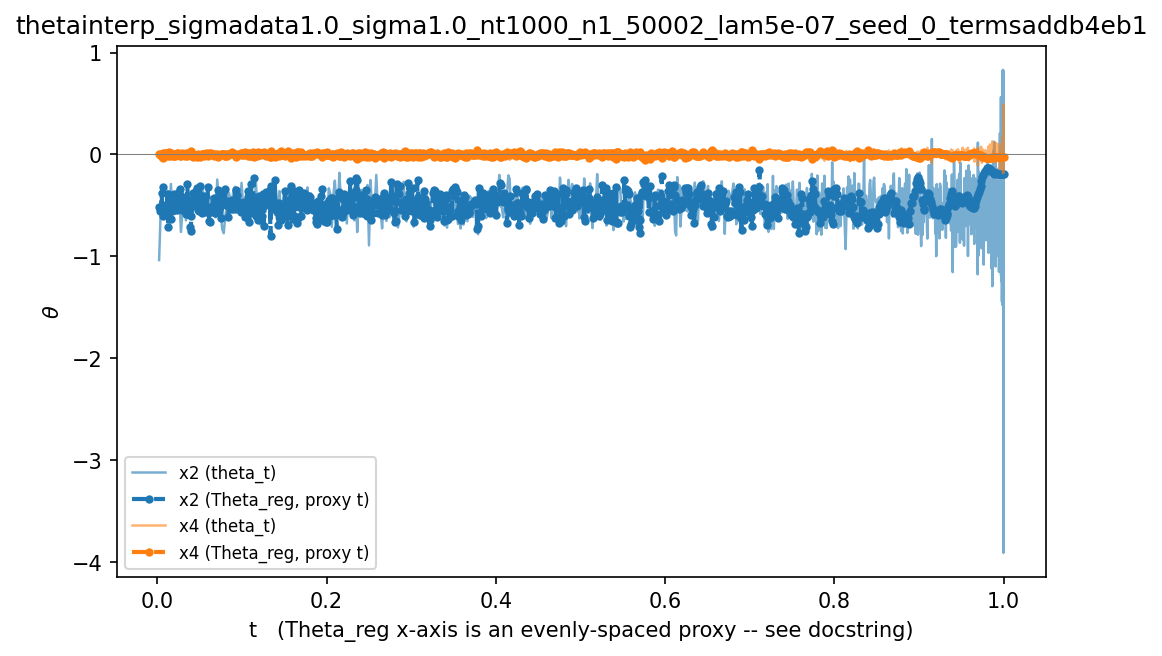

In [11]:
plot_theta_reg_overlay(
    run_wrong['result']['theta_t'], run_wrong['result']['Theta_reg'],
    run_wrong['result']['t'], term_names_wrong,
    run_wrong['fig_dir'], run_wrong['config'],
)
display(Image(filename=str(run_wrong['fig_dir'] / 'theta_reg_overlay.png')))


In [12]:
term_names_wrong = list(get_scalar_potentials(run_wrong['args'].terms).keys())
theta_final_wrong = run_wrong['result']['theta_t'][-1].detach().cpu()

print('terms:', term_names_wrong)
print('fitted theta[-1]:', theta_final_wrong.tolist())


terms: ['x2', 'x4']
fitted theta[-1]: [-2.8022193908691406, 0.11775221675634384]


## Side-by-side comparison

If the fit is well-behaved, `theta_x2` should land close to the same value
in both runs (the reference computed above), and the misspecified run's
`theta_x4` should be small relative to `theta_x2` — the model correctly
"discovering" that the quartic term isn't needed.


In [13]:
i2_correct = term_names_correct.index('x2')
i2_wrong = term_names_wrong.index('x2')
i4_wrong = term_names_wrong.index('x4')

print(f"theta_x2, correct model      : {theta_final_correct[i2_correct].item(): .6f}")
print(f"theta_x2, misspecified model : {theta_final_wrong[i2_wrong].item(): .6f}")
print(f"theta_x4, misspecified model : {theta_final_wrong[i4_wrong].item(): .6f}  (expected near 0)")
print(f"reference target theta_x2    : {target_theta_x2: .6f}")


theta_x2, correct model      : -2.081999
theta_x2, misspecified model : -2.802219
theta_x4, misspecified model :  0.117752  (expected near 0)
reference target theta_x2    : -0.500000
